<a href="https://colab.research.google.com/github/stnewaz/Computer-Vision-Project/blob/condensed_data_training/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing required Libraries

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow import keras
import cv2
import seaborn as sns
import glob
import xml.etree.ElementTree as ET
from PIL import Image
import os
import shutil

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Custom object detection using YOLO

First install and import

In [4]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.218  Python-3.13.7 torch-2.9.0+cpu CPU (AMD Ryzen 7 PRO 5875U with Radeon Graphics)
Setup complete  (16 CPUs, 14.8 GB RAM, 220.8/236.3 GB disk)


In [5]:
from ultralytics import YOLO

## Training YOLO - Lab Example

We are going to select small pretrained (on COCO dataset) model of YOLOv8

In [6]:
model = YOLO('yolo11s-cls.pt') # pretrained model

Please look at [Yolo train Docs](https://docs.ultralytics.com/modes/train/#train-settings) for hyperparameters for model tuning and configuration, e.g. lr0, imgsz, model etc.

In [8]:
model.train(data="S:\\important_backup\\school_backup\\iat360\\data_condensed_training\\data_condensed",epochs=5,patience=5,batch=8, lr0=0.0005,imgsz=400, plots=True)

New https://pypi.org/project/ultralytics/8.3.223 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.218  Python-3.13.7 torch-2.9.0+cpu CPU (AMD Ryzen 7 PRO 5875U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=S:\important_backup\school_backup\iat360\data_condensed_training\data_condensed, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=400, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937, mo

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001AA95CBA690>
curves: []
curves_results: []
fitness: 0.7752525210380554
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.6111111044883728, 'metrics/accuracy_top5': 0.939393937587738, 'fitness': 0.7752525210380554}
save_dir: WindowsPath('C:/Users/selen/runs/classify/train')
speed: {'preprocess': 0.003495454483058755, 'inference': 66.43470555556836, 'loss': 0.00015606054497619318, 'postprocess': 0.0004252526030706411}
task: 'classify'
top1: 0.6111111044883728
top5: 0.939393937587738

## Evaluation Metrics

[This](https://docs.ultralytics.com/guides/yolo-performance-metrics/) is a very good detailed explanation of different perfromance metrics in YOLO.

**Choosing the Right Metrics**

Choosing the right metrics to evaluate often depends on the specific application.

- mAP: Suitable for a broad assessment of model performance.

- IoU: Essential when precise object location is crucial.

- Precision: Important when minimizing false detections is a priority.

- Recall: Vital when it's important to detect every instance of an object.

- F1 Score: Useful when a balance between precision and recall is needed.


In [11]:
metrics = model.val()  # no arguments needed, dataset and settings remembered
# print(metrics.f1)
#metrics.box.map    # map50-95
#metrics.box.map50  # map50
#metrics.box.map75  # map75
#metrics.box.maps   # a list contains map50-95 of each category
#metrics.box.mp    # P
#metrics.box.mr    # R

Ultralytics 8.3.218  Python-3.13.7 torch-2.9.0+cpu CPU (AMD Ryzen 7 PRO 5875U with Radeon Graphics)
train: S:\important_backup\school_backup\iat360\data_condensed_training\data_condensed\train... found 2317 images in 7 classes  
val: S:\important_backup\school_backup\iat360\data_condensed_training\data_condensed\val... found 198 images in 7 classes  
test: S:\important_backup\school_backup\iat360\data_condensed_training\data_condensed\test... found 207 images in 7 classes  
val: Fast image access  (ping: 0.10.0 ms, read: 455.1306.6 MB/s, size: 159.2 KB)
val: Scanning S:\important_backup\school_backup\iat360\data_condensed_training\data_condensed\val... 198 images, 0 corrupt: 100% ━━━━━━━━━━━━ 198/198 126.7Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 13/13 0.5it/s 24.0s
                   all      0.611      0.939
Speed: 0.0ms preprocess, 49.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to C:\Users\selen\runs\classify\val3


Showing confusion matrix, that is already stored in detect/train folder

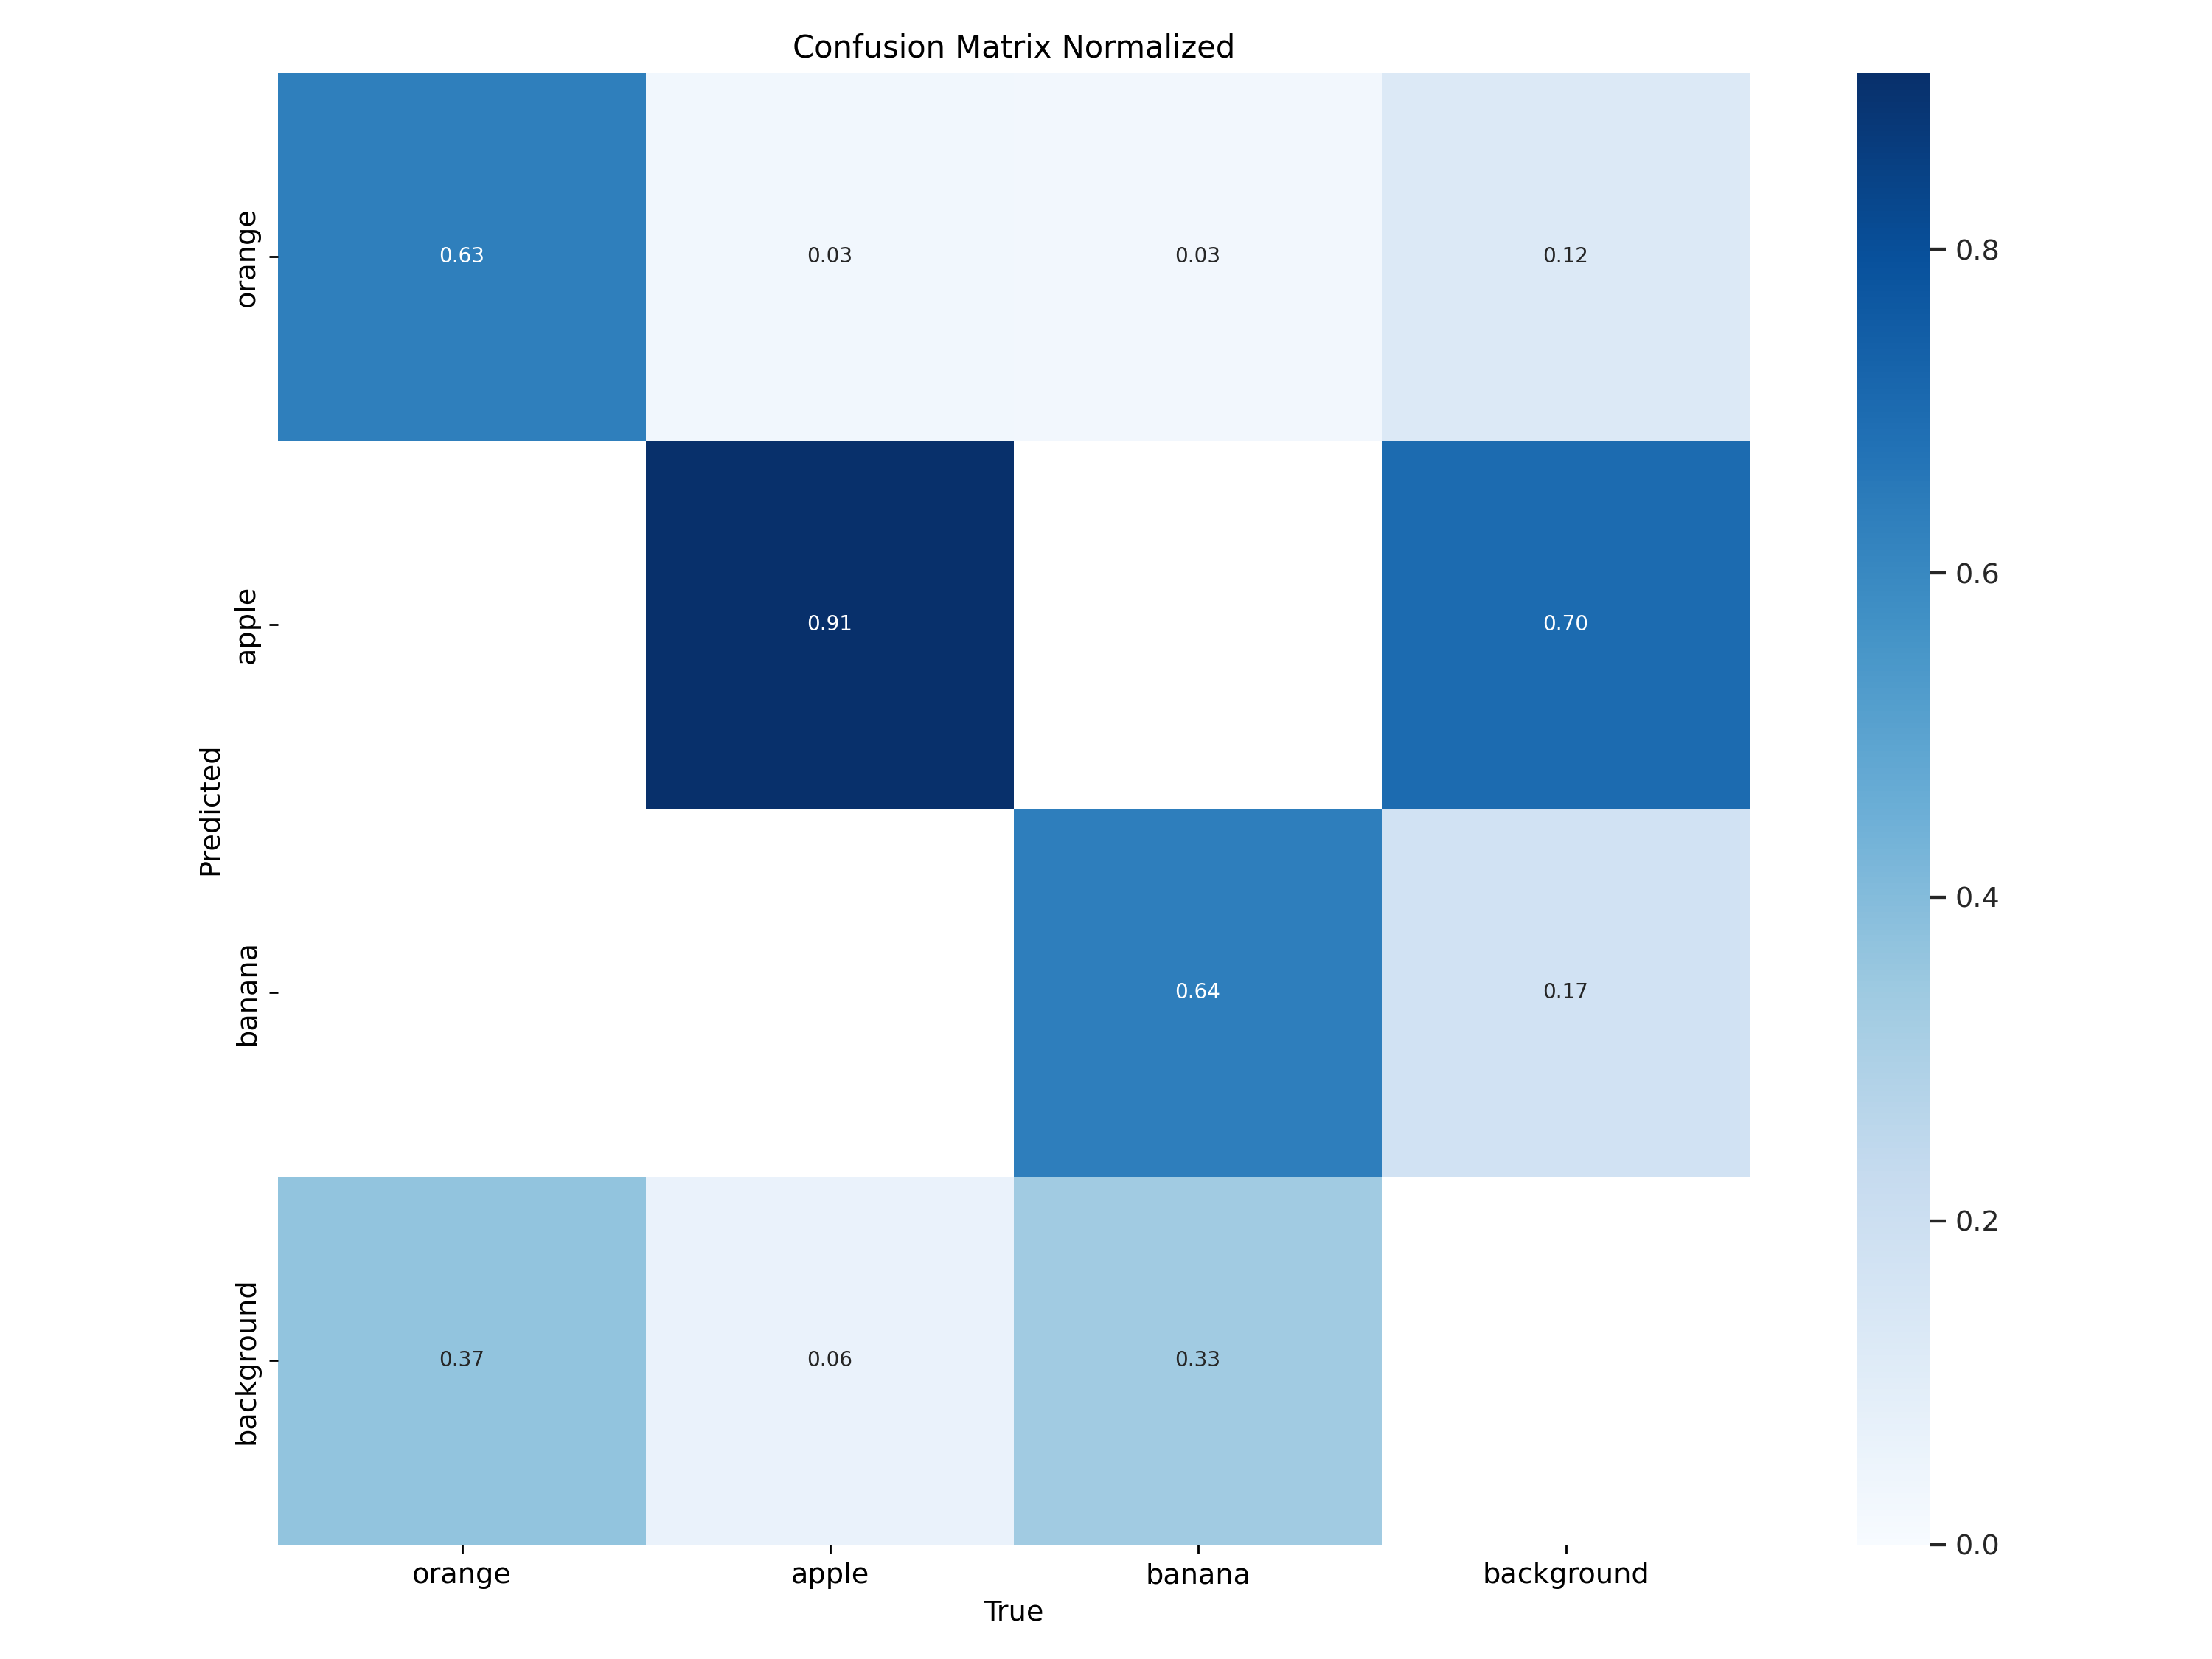

In [ ]:
%matplotlib inline
from PIL import Image

Image.open('/content/runs/detect/train/confusion_matrix_normalized.png')

In [23]:
import pandas as pd
import numpy as np

# # Assuming 'metrics.confusion_matrix' or similar attribute holds the matrix data
# # (You might need to inspect the 'metrics' object to find the exact attribute)
# confusion_matrix_data = metrics.confusion_matrix.matrix # Example: Adjust based on your YOLO version

# # Convert to a Pandas DataFrame
# df_cm = pd.DataFrame(confusion_matrix_data, index=model.names, columns=model.names)

# # Export to CSV
# df_cm.to_csv("confusion_matrix.csv")


confusion_matrix_df = metrics.confusion_matrix.to_df()
# print(confusion_matrix_df)

df = pd.DataFrame(confusion_matrix_df)
df.to_csv("confusion_matrix.csv")
# confusion_matrix_df.to_csv("confusion_matrix.csv")

In [18]:
confusion_matrix_df

Predicted,Chemtrails,Cirriform,Cumulonimbus,Cumulus,High_Cumuliform,Stratiform,Stratocumulus,background
str,f64,f64,f64,f64,f64,f64,f64,f64
"""Chemtrails""",15.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0
"""Cirriform""",3.0,8.0,2.0,2.0,2.0,0.0,0.0,0.0
"""Cumulonimbus""",0.0,0.0,3.0,0.0,2.0,1.0,2.0,0.0
"""Cumulus""",0.0,0.0,3.0,4.0,2.0,0.0,0.0,0.0
"""High_Cumuliform""",0.0,0.0,0.0,1.0,23.0,1.0,1.0,0.0
"""Stratiform""",0.0,10.0,10.0,11.0,6.0,66.0,13.0,0.0
"""Stratocumulus""",0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
"""background""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##Prediction

In [ ]:
model = YOLO('/content/runs/classify/train6/weights/best.pt')  # load a custom model

# Predict with the model with any image from internet?
results = model('/content/drive/MyDrive/archive (2)/data/test/Cb', save=True)


image 1/26 /content/drive/MyDrive/archive (2)/data/test/Cb/1.jpg: 416x416 Cb 0.85, Cu 0.10, St 0.02, Sc 0.02, Ac 0.00, 5.5ms
image 2/26 /content/drive/MyDrive/archive (2)/data/test/Cb/103.jpg: 416x416 St 0.42, Cu 0.15, Cb 0.14, Ac 0.10, Ns 0.08, 6.2ms
image 3/26 /content/drive/MyDrive/archive (2)/data/test/Cb/114.jpg: 416x416 Cb 0.95, Cu 0.05, St 0.00, As 0.00, Ac 0.00, 5.5ms
image 4/26 /content/drive/MyDrive/archive (2)/data/test/Cb/120.jpg: 416x416 Cb 0.41, St 0.34, Cc 0.08, Sc 0.07, Cu 0.04, 5.5ms
image 5/26 /content/drive/MyDrive/archive (2)/data/test/Cb/127.jpg: 416x416 Cs 0.63, Sc 0.28, Ci 0.05, St 0.01, Cc 0.01, 5.5ms
image 6/26 /content/drive/MyDrive/archive (2)/data/test/Cb/134.jpg: 416x416 Cb 0.98, Cu 0.02, As 0.00, Ac 0.00, St 0.00, 5.5ms
image 7/26 /content/drive/MyDrive/archive (2)/data/test/Cb/141.jpg: 416x416 St 0.38, Ns 0.31, Cb 0.13, As 0.07, Sc 0.04, 5.5ms
image 8/26 /content/drive/MyDrive/archive (2)/data/test/Cb/142.jpg: 416x416 Cb 0.95, Cu 0.04, St 0.01, Sc 0.00, 

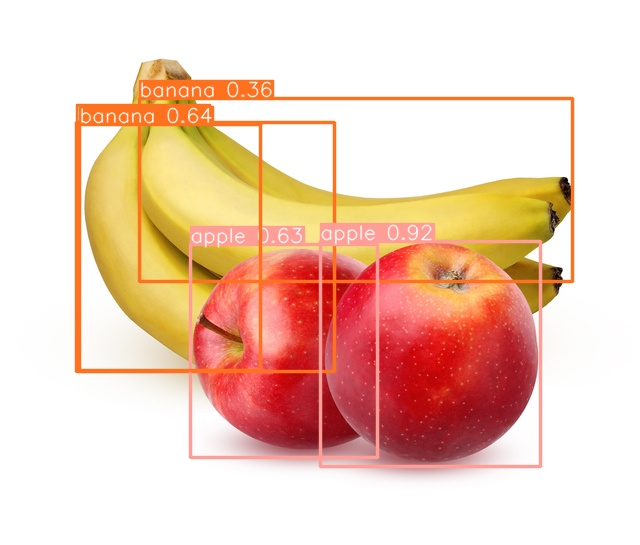

In [ ]:
# SHOW THE IMAGE STORED
%matplotlib inline
from PIL import Image

Image.open('/content/runs/detect/predict/freshpoint-produce-101-apples-bananas.jpg')

In [24]:
model_tuned = YOLO('yolo11s-cls.pt') # pretrained model

In [25]:
model_tuned.train(data="S:\\important_backup\\school_backup\\iat360\\data_condensed_training\\data_condensed",epochs=20,patience=5,batch=16, lr0=0.0005,imgsz=400, plots=True)

New https://pypi.org/project/ultralytics/8.3.223 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.218  Python-3.13.7 torch-2.9.0+cpu CPU (AMD Ryzen 7 PRO 5875U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=S:\important_backup\school_backup\iat360\data_condensed_training\data_condensed, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=400, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937, 

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001AA8C438A50>
curves: []
curves_results: []
fitness: 0.7424242496490479
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.5505050420761108, 'metrics/accuracy_top5': 0.9343434572219849, 'fitness': 0.7424242496490479}
save_dir: WindowsPath('C:/Users/selen/runs/classify/train2')
speed: {'preprocess': 0.0012757574417393165, 'inference': 44.44908686825944, 'loss': 4.8990125034117334e-05, 'postprocess': 0.00015555512315283218}
task: 'classify'
top1: 0.5505050420761108
top5: 0.9343434572219849

In [26]:
metrics_tuned = model_tuned.val()

Ultralytics 8.3.218  Python-3.13.7 torch-2.9.0+cpu CPU (AMD Ryzen 7 PRO 5875U with Radeon Graphics)
YOLO11s-cls summary (fused): 47 layers, 5,443,095 parameters, 0 gradients, 12.0 GFLOPs
train: S:\important_backup\school_backup\iat360\data_condensed_training\data_condensed\train... found 2317 images in 7 classes  
val: S:\important_backup\school_backup\iat360\data_condensed_training\data_condensed\val... found 198 images in 7 classes  
test: S:\important_backup\school_backup\iat360\data_condensed_training\data_condensed\test... found 207 images in 7 classes  
val: Fast image access  (ping: 0.10.0 ms, read: 196.1135.9 MB/s, size: 159.2 KB)
val: Scanning S:\important_backup\school_backup\iat360\data_condensed_training\data_condensed\val... 198 images, 0 corrupt: 100% ━━━━━━━━━━━━ 198/198 280.5Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 13/13 0.8it/s 16.4s
                   all      0.551      0.934
Speed: 0.0ms preprocess, 39.0ms inference, 0.0ms loss, 0.0

In [ ]:
model = YOLO("C:/Users/selen/runs/classify/train2/weights/best.pt")  # load a custom model

# Predict with the model with any image from internet?
results = model('/content/drive/MyDrive/archive (2)/data/test/Cb', save=True)


image 1/26 /content/drive/MyDrive/archive (2)/data/test/Cb/1.jpg: 416x416 Cb 0.85, Cu 0.10, St 0.02, Sc 0.02, Ac 0.00, 5.5ms
image 2/26 /content/drive/MyDrive/archive (2)/data/test/Cb/103.jpg: 416x416 St 0.42, Cu 0.15, Cb 0.14, Ac 0.10, Ns 0.08, 6.2ms
image 3/26 /content/drive/MyDrive/archive (2)/data/test/Cb/114.jpg: 416x416 Cb 0.95, Cu 0.05, St 0.00, As 0.00, Ac 0.00, 5.5ms
image 4/26 /content/drive/MyDrive/archive (2)/data/test/Cb/120.jpg: 416x416 Cb 0.41, St 0.34, Cc 0.08, Sc 0.07, Cu 0.04, 5.5ms
image 5/26 /content/drive/MyDrive/archive (2)/data/test/Cb/127.jpg: 416x416 Cs 0.63, Sc 0.28, Ci 0.05, St 0.01, Cc 0.01, 5.5ms
image 6/26 /content/drive/MyDrive/archive (2)/data/test/Cb/134.jpg: 416x416 Cb 0.98, Cu 0.02, As 0.00, Ac 0.00, St 0.00, 5.5ms
image 7/26 /content/drive/MyDrive/archive (2)/data/test/Cb/141.jpg: 416x416 St 0.38, Ns 0.31, Cb 0.13, As 0.07, Sc 0.04, 5.5ms
image 8/26 /content/drive/MyDrive/archive (2)/data/test/Cb/142.jpg: 416x416 Cb 0.95, Cu 0.04, St 0.01, Sc 0.00, 